In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

col_names = ['engine_id', 'cycle',
             'setting1', 'setting2', 'setting3',
             's1','s2','s3','s4','s5','s6','s7',
             's8','s9','s10','s11','s12','s13',
             's14','s15','s16','s17','s18','s19',
             's20','s21']

SENSOR_COLS  = [f's{i}' for i in range(1, 22)]
SETTING_COLS = ['setting1', 'setting2', 'setting3']
SUBSETS      = ['FD001', 'FD002', 'FD003', 'FD004']
DATA_DIR     = '../data/raw'

def load_raw(subset):
    kw = dict(sep=r'\s+', header=None, names=col_names, engine='python')
    train = pd.read_csv(f'{DATA_DIR}/train_{subset}.txt', **kw)
    test  = pd.read_csv(f'{DATA_DIR}/test_{subset}.txt',  **kw)
    rul   = pd.read_csv(f'{DATA_DIR}/RUL_{subset}.txt', header=None, names=['RUL'])
    return train, test, rul

data = {s: load_raw(s) for s in SUBSETS}
print('Loaded:', list(data.keys()))

Loaded: ['FD001', 'FD002', 'FD003', 'FD004']


In [2]:
rows = []
for subset, (train, test, rul) in data.items():
    lifetimes = train.groupby('engine_id')['cycle'].max()
    rows.append({
        'Subset'        : subset,
        'Train engines' : train['engine_id'].nunique(),
        'Test engines'  : test['engine_id'].nunique(),
        'Train rows'    : len(train),
        'Avg lifetime'  : round(lifetimes.mean(), 1),
        'Min lifetime'  : lifetimes.min(),
        'Max lifetime'  : lifetimes.max(),
        'Avg test RUL'  : round(rul['RUL'].mean(), 1),
    })

overview = pd.DataFrame(rows).set_index('Subset')
print(overview.to_string())

        Train engines  Test engines  Train rows  Avg lifetime  Min lifetime  Max lifetime  Avg test RUL
Subset                                                                                                 
FD001             100           100       20631         206.3           128           362          75.5
FD002             260           259       53759         206.8           128           378          81.2
FD003             100           100       24720         247.2           145           525          75.3
FD004             249           248       61249         246.0           128           543          86.6


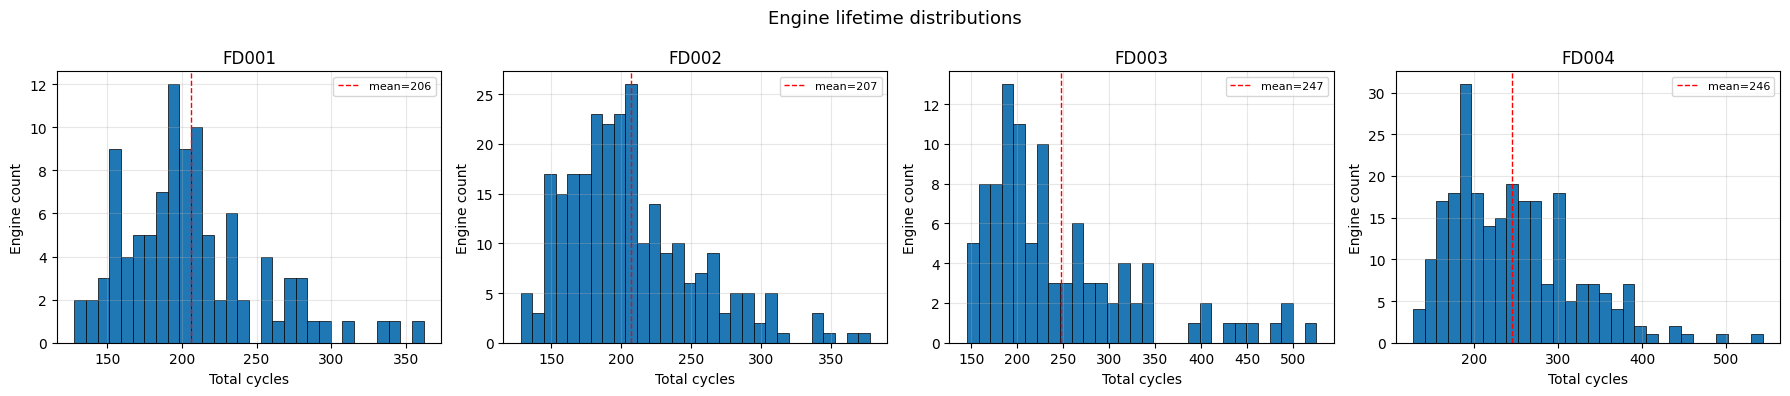

In [3]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, subset in zip(axes, SUBSETS):
    train, _, _ = data[subset]
    lifetimes = train.groupby('engine_id')['cycle'].max()
    ax.hist(lifetimes, bins=30, edgecolor='black', linewidth=0.5)
    ax.axvline(lifetimes.mean(), color='red', linestyle='--', linewidth=1,
               label=f'mean={lifetimes.mean():.0f}')
    ax.set_title(subset)
    ax.set_xlabel('Total cycles')
    ax.set_ylabel('Engine count')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Engine lifetime distributions', fontsize=13)
plt.tight_layout()
plt.show()

In [4]:
for subset in SUBSETS:
    train, _, _ = data[subset]
    rounded = train[SETTING_COLS].round(0).drop_duplicates()
    print(f'{subset}: {len(rounded)} unique operating points')
    print(rounded.to_string(index=False))
    print()

FD001: 1 unique operating points
 setting1  setting2  setting3
     -0.0      -0.0     100.0

FD002: 6 unique operating points
 setting1  setting2  setting3
     35.0       1.0     100.0
     42.0       1.0     100.0
     25.0       1.0      60.0
     20.0       1.0     100.0
      0.0       0.0     100.0
     10.0       0.0     100.0

FD003: 1 unique operating points
 setting1  setting2  setting3
     -0.0       0.0     100.0

FD004: 6 unique operating points
 setting1  setting2  setting3
     42.0       1.0     100.0
     20.0       1.0     100.0
     25.0       1.0      60.0
     35.0       1.0     100.0
      0.0       0.0     100.0
     10.0       0.0     100.0



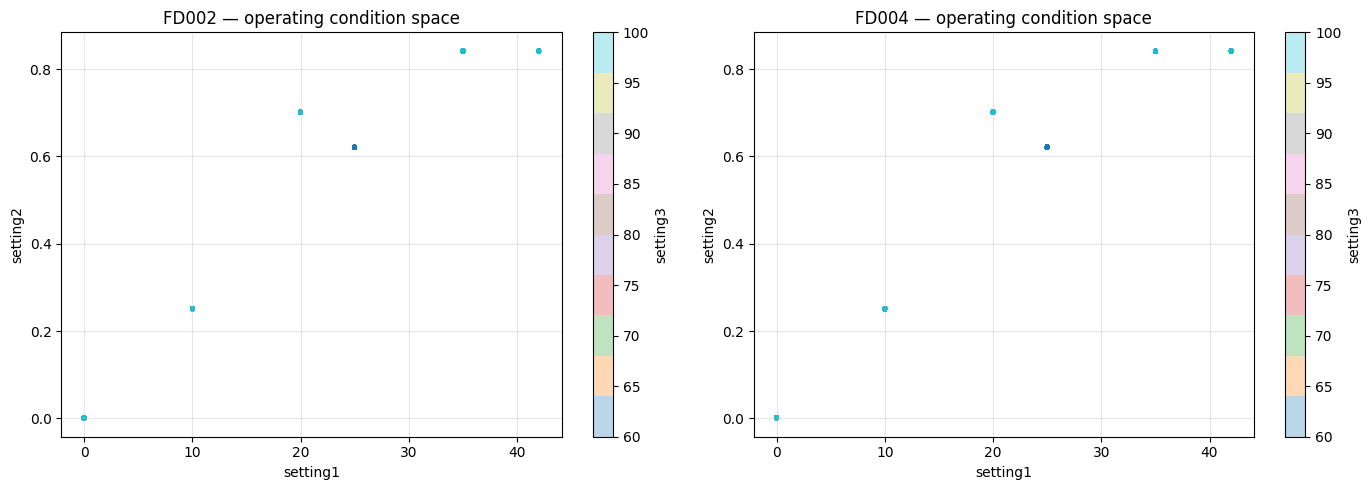

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, subset in zip(axes, ['FD002', 'FD004']):
    train, _, _ = data[subset]
    sc = ax.scatter(train['setting1'], train['setting2'],
                    c=train['setting3'], cmap='tab10', alpha=0.3, s=5)
    plt.colorbar(sc, ax=ax, label='setting3')
    ax.set_xlabel('setting1')
    ax.set_ylabel('setting2')
    ax.set_title(f'{subset} — operating condition space')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

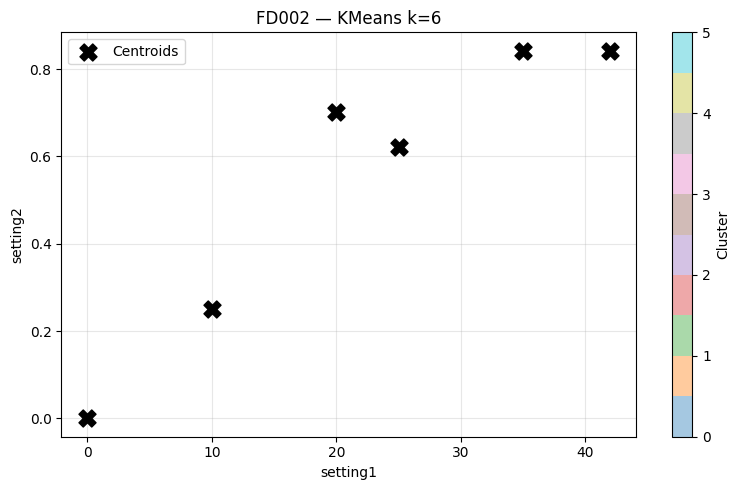

Cluster 0: 13458 rows (25.0%)
Cluster 1: 8122 rows (15.1%)
Cluster 2: 8002 rows (14.9%)
Cluster 3: 8044 rows (15.0%)
Cluster 4: 8096 rows (15.1%)
Cluster 5: 8037 rows (15.0%)


In [6]:
train_fd002, _, _ = data['FD002']
train_fd002 = train_fd002.copy()

km = KMeans(n_clusters=6, random_state=42, n_init=10)
train_fd002['cluster'] = km.fit_predict(train_fd002[SETTING_COLS])

fig, ax = plt.subplots(figsize=(8, 5))
sc = ax.scatter(train_fd002['setting1'], train_fd002['setting2'],
                c=train_fd002['cluster'], cmap='tab10', alpha=0.4, s=5)
ax.scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1],
           marker='X', s=150, c='black', zorder=5, label='Centroids')
plt.colorbar(sc, ax=ax, label='Cluster')
ax.set_xlabel('setting1')
ax.set_ylabel('setting2')
ax.set_title('FD002 — KMeans k=6')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

unique, counts = np.unique(train_fd002['cluster'], return_counts=True)
for c, n in zip(unique, counts):
    print(f'Cluster {c}: {n} rows ({100*n/len(train_fd002):.1f}%)')

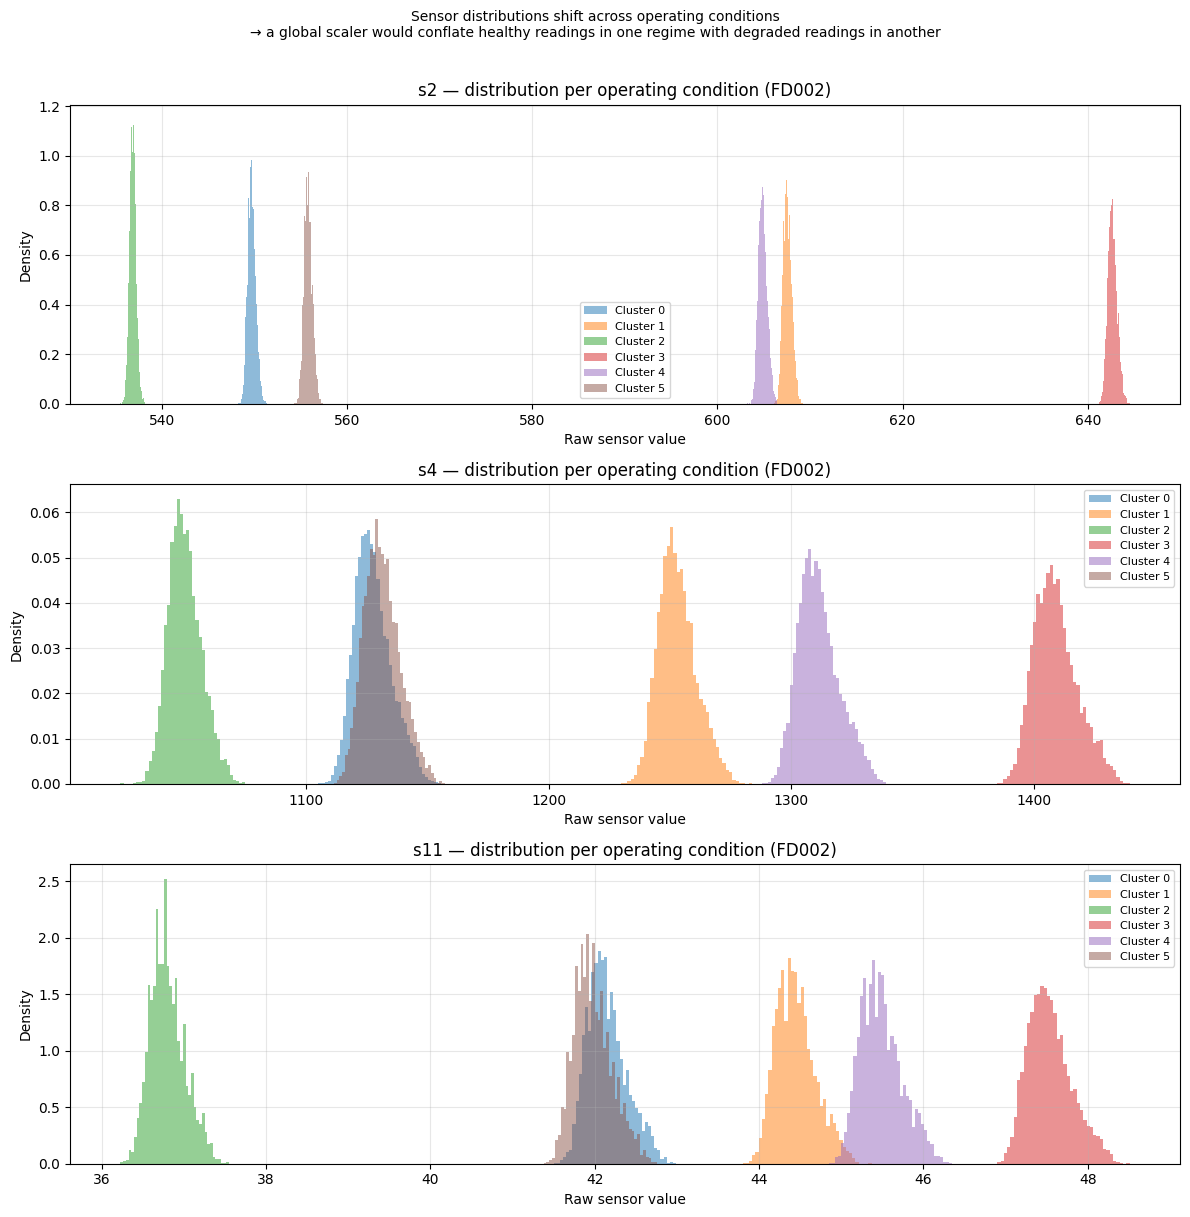

In [7]:
sensors_to_plot = ['s2', 's4', 's11']

fig, axes = plt.subplots(3, 1, figsize=(12, 12))

for ax, sensor in zip(axes, sensors_to_plot):
    for cluster_id in sorted(train_fd002['cluster'].unique()):
        vals = train_fd002[train_fd002['cluster'] == cluster_id][sensor]
        ax.hist(vals, bins=40, alpha=0.5, label=f'Cluster {cluster_id}', density=True)
    ax.set_title(f'{sensor} — distribution per operating condition (FD002)')
    ax.set_xlabel('Raw sensor value')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Sensor distributions shift across operating conditions\n'
             '→ a global scaler would conflate healthy readings in one regime with degraded readings in another',
             fontsize=10, y=1.01)
plt.tight_layout()
plt.show()

In [8]:
summary = train_fd002.groupby('cluster')[sensors_to_plot].mean().round(2)
print('Per-cluster MEAN of key sensors (FD002):')
print(summary.to_string())
print()
print('Range (max mean - min mean):')
print((summary.max() - summary.min()).round(2))

Per-cluster MEAN of key sensors (FD002):
             s2       s4    s11
cluster                        
0        549.70  1127.80  42.15
1        607.56  1253.12  44.45
2        536.87  1050.32  36.80
3        642.68  1408.86  47.54
4        604.91  1311.25  45.49
5        555.80  1131.53  41.98

Range (max mean - min mean):
s2     105.81
s4     358.54
s11     10.74
dtype: float64


In [9]:
global_std = {}
for subset in SUBSETS:
    train, _, _ = data[subset]
    global_std[subset] = train[SENSOR_COLS].std()

std_df = pd.DataFrame(global_std).round(4)
std_df.index.name = 'sensor'
print('Global std per sensor per subset:')
print(std_df.to_string())

print('\nFlat globally (std < 0.05) per subset:')
for subset in SUBSETS:
    flat = std_df[subset][std_df[subset] < 0.05].index.tolist()
    print(f'  {subset}: {flat}')

Global std per sensor per subset:
          FD001     FD002    FD003     FD004
sensor                                      
s1       0.0000   26.3897   0.0000   26.4368
s2       0.5001   37.2894   0.5230   37.3426
s3       6.1311  105.9463   6.8104  106.1676
s4       9.0006  119.1234   9.7732  119.3276
s5       0.0000    3.6138   0.0000    3.6229
s6       0.0014    5.4318   0.0181    5.4440
s7       0.8851  146.0053   3.4373  146.8802
s8       0.0710  145.2098   0.1583  145.3482
s9      22.0829  335.8120  19.9803  336.9275
s10      0.0000    0.1275   0.0035    0.1277
s11      0.2671    3.2324   0.3001    3.2435
s12      0.7376  137.6595   3.2553  138.4791
s13      0.0719  128.0683   0.1581  128.1979
s14     19.0762   84.8379  16.5041   85.6705
s15      0.0375    0.7493   0.0605    0.7504
s16      0.0000    0.0047   0.0000    0.0047
s17      1.5488   27.7545   1.7615   27.8083
s18      0.0000  145.3280   0.0000  145.4725
s19      0.0000    5.3641   0.0000    5.3694
s20      0.1807    9.

In [10]:
def within_cluster_std(train_df, n_clusters=6):
    df = train_df.copy()
    km = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    df['cluster'] = km.fit_predict(df[SETTING_COLS])
    # mean of per-cluster std across all clusters
    return df.groupby('cluster')[SENSOR_COLS].std().mean()

wc_fd002 = within_cluster_std(data['FD002'][0])
wc_fd004 = within_cluster_std(data['FD004'][0])

print('Within-cluster std — FD002 (sorted):')
print(wc_fd002.sort_values().to_string())

print('\nWithin-cluster std — FD004 (sorted):')
print(wc_fd004.sort_values().to_string())

Within-cluster std — FD002 (sorted):
s1      0.000000
s19     0.000000
s18     0.000000
s5      0.000000
s16     0.000684
s10     0.001458
s6      0.003588
s15     0.038828
s21     0.078140
s20     0.131632
s8      0.188776
s13     0.199709
s11     0.238597
s2      0.443996
s12     0.471193
s7      0.584790
s17     1.430415
s3      5.687575
s4      7.839283
s14    15.440292
s9     17.296189

Within-cluster std — FD004 (sorted):
s1      0.000000
s19     0.000000
s18     0.000000
s5      0.000000
s16     0.000647
s10     0.004654
s6      0.014807
s15     0.067076
s21     0.099981
s20     0.166924
s8      0.206728
s13     0.216963
s11     0.279424
s2      0.479253
s17     1.629290
s12     1.784017
s7      1.902518
s3      6.456879
s4      8.860799
s14    15.285537
s9     17.600679


In [11]:
FLAT_THRESHOLD = 0.05

flat_sensors = {}

# FD001 + FD003: one operating condition, use global std
for subset in ['FD001', 'FD003']:
    train, _, _ = data[subset]
    s = train[SENSOR_COLS].std()
    flat_sensors[subset] = s[s < FLAT_THRESHOLD].index.tolist()

# FD002 + FD004: use within-cluster std
flat_sensors['FD002'] = wc_fd002[wc_fd002 < FLAT_THRESHOLD].index.tolist()
flat_sensors['FD004'] = wc_fd004[wc_fd004 < FLAT_THRESHOLD].index.tolist()

print('Sensors to drop per subset:')
for subset, sensors in flat_sensors.items():
    print(f'  {subset}: {sensors}')

sets = [set(v) for v in flat_sensors.values()]
always_flat    = sets[0].intersection(*sets[1:])
sometimes_flat = set().union(*sets) - always_flat

print(f'\nFlat in ALL subsets (drop everywhere):  {sorted(always_flat)}')
print(f'Flat in some but not all:               {sorted(sometimes_flat)}')

Sensors to drop per subset:
  FD001: ['s1', 's5', 's6', 's10', 's15', 's16', 's18', 's19']
  FD003: ['s1', 's5', 's6', 's10', 's16', 's18', 's19']
  FD002: ['s1', 's5', 's6', 's10', 's15', 's16', 's18', 's19']
  FD004: ['s1', 's5', 's6', 's10', 's16', 's18', 's19']

Flat in ALL subsets (drop everywhere):  ['s1', 's10', 's16', 's18', 's19', 's5', 's6']
Flat in some but not all:               ['s15']


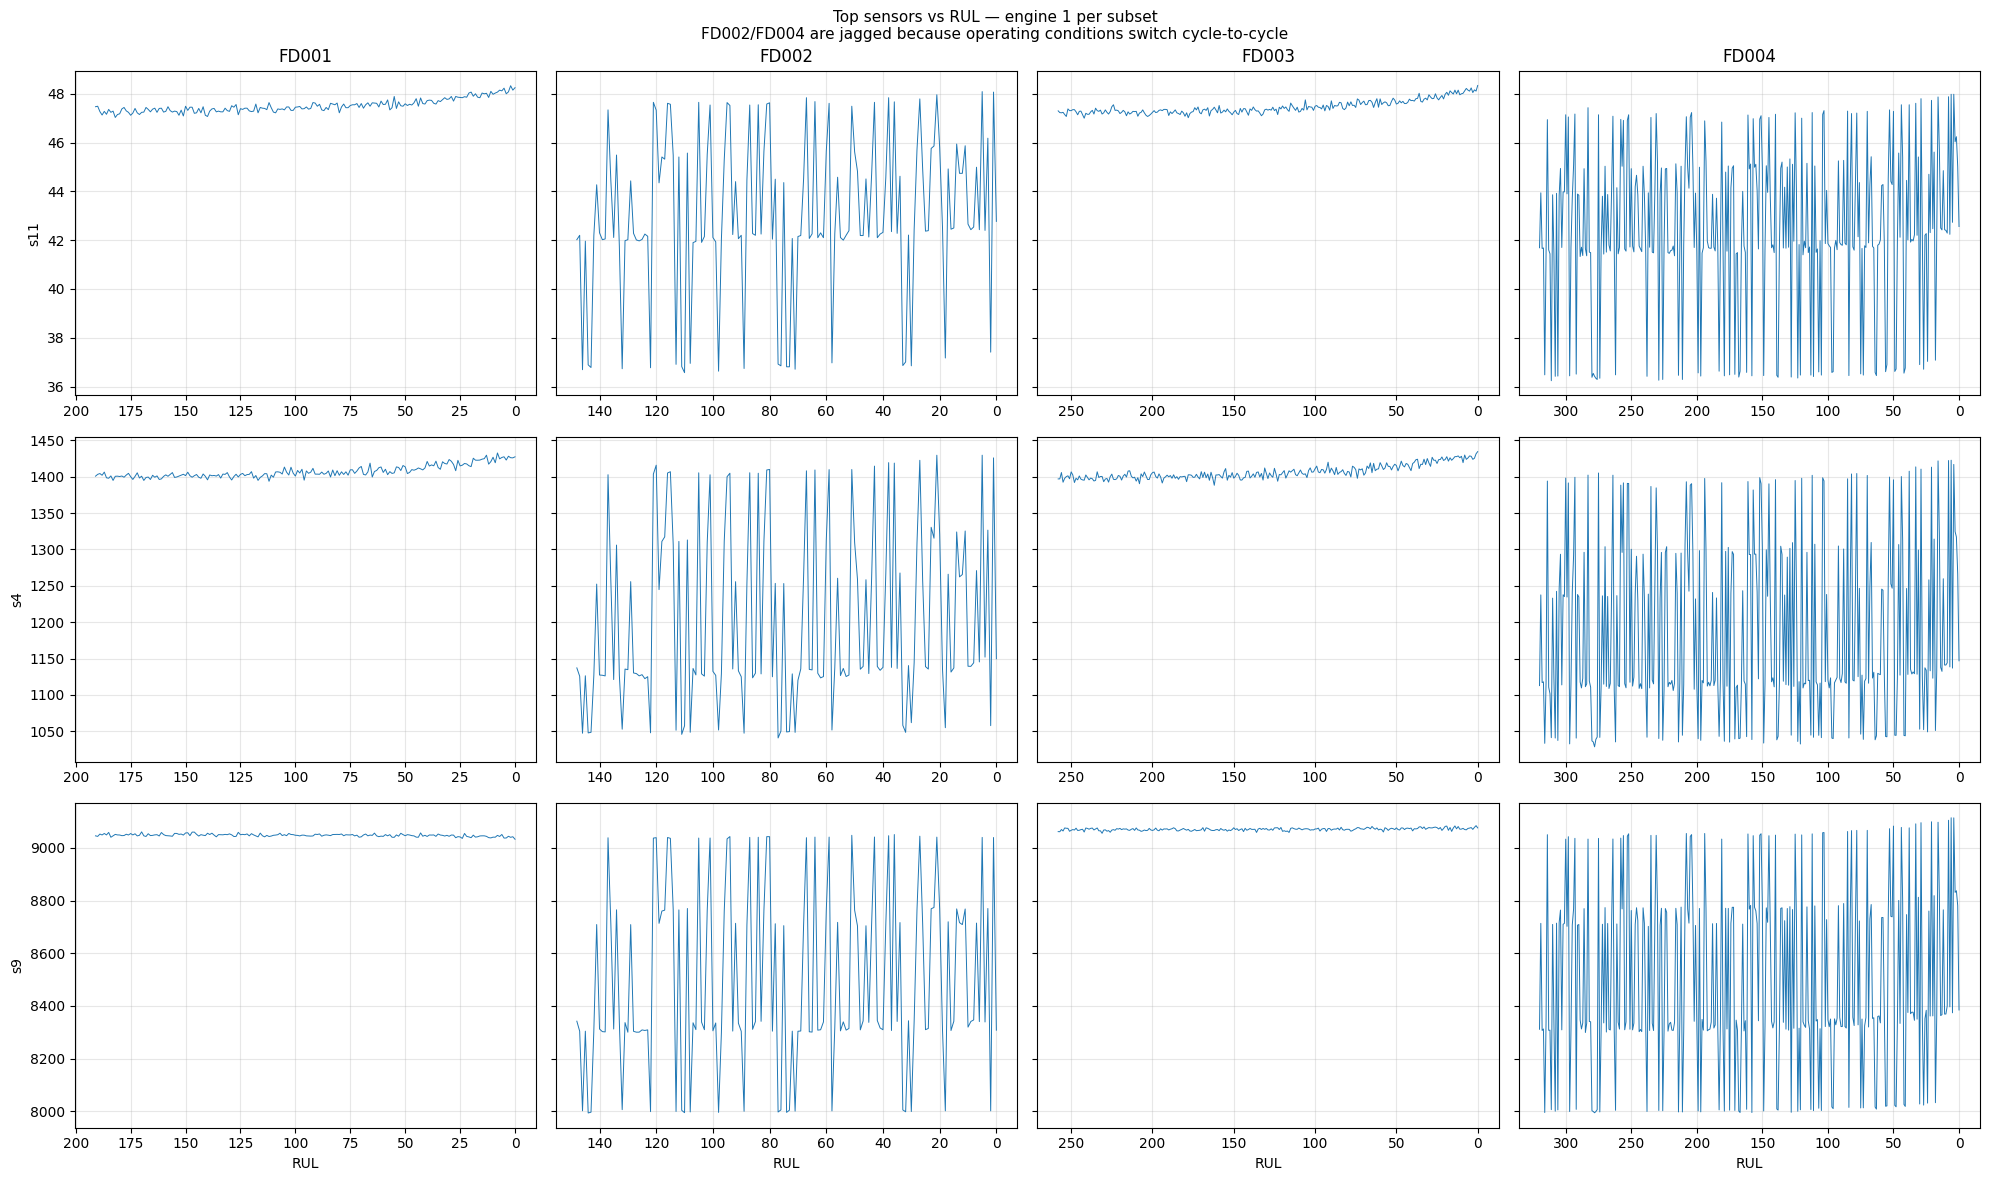

In [12]:
TOP_SENSORS = ['s11', 's4', 's9']

fig, axes = plt.subplots(3, 4, figsize=(20, 12), sharey='row')

for col, subset in enumerate(SUBSETS):
    train, _, _ = data[subset]
    train = train.copy()
    max_cycles = train.groupby('engine_id')['cycle'].max()
    train['RUL'] = train['engine_id'].map(max_cycles) - train['cycle']
    engine_1 = train[train['engine_id'] == 1].sort_values('cycle')

    for row, sensor in enumerate(TOP_SENSORS):
        ax = axes[row][col]
        ax.plot(engine_1['RUL'], engine_1[sensor], linewidth=0.7)
        ax.invert_xaxis()
        ax.grid(True, alpha=0.3)
        if row == 0:
            ax.set_title(subset, fontsize=12)
        if col == 0:
            ax.set_ylabel(sensor)
        if row == 2:
            ax.set_xlabel('RUL')

plt.suptitle('Top sensors vs RUL — engine 1 per subset\n'
             'FD002/FD004 are jagged because operating conditions switch cycle-to-cycle',
             fontsize=11)
plt.tight_layout()
plt.show()